In [1]:
# Importação das bibliotecas necessárias

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from modulos import preparar_breast_cancer, avaliar_modelo, exibir_resultado, exibir_relatorio_de_classificacao, gerar_grafico_da_arvore_de_decisao, treinar_k, atualizar_melhor_desempenho_k, exibir_melhor_resultado_do_knn, exibir_grafico_comparativo, executar_arvore_de_decisao, executar_naive_bayes
from sklearn.tree import DecisionTreeClassifier, export_text


In [2]:
# Importação e exploração dos dados
breast_cancer = load_breast_cancer()
X, y, feature_names, target_names = preparar_breast_cancer(breast_cancer)

# Divisão em Treino (70%) e Teste (30%) com semente fixa para reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=13, stratify=y
)

In [3]:
(clf, y_pred_arvore_de_decisao, acuracia_arvore_decisao, precisao_arvore_decisao,
revocacao_arvore_decisao, f1_arvore_decisao) = executar_arvore_de_decisao(X_train, y_train, X_test, y_test)


In [4]:
# Exibição dos resultados das métricas usando Árvore de Decisão com Breast Cancer
exibir_resultado(
    acuracia_arvore_decisao, precisao_arvore_decisao,
    revocacao_arvore_decisao, f1_arvore_decisao,
    "ÁRVORE DE DECISÃO"
    )


MÉTRICAS DE AVALIAÇÃO - ÁRVORE DE DECISÃO
Acurácia:  0.9006
Precisão:  0.9000
Revocação: 0.8860
F1-Score:  0.8921




In [5]:
# Exibição das Regras Geradas (Exigência do Relatório)
print("\nREGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):")
regras_texto = export_text(clf, feature_names=feature_names)
print(regras_texto)
print("=" * 50)



REGRAS DA ÁRVORE DE DECISÃO (FORMATO TEXTO):
|--- worst area <= 884.55
|   |--- worst concave points <= 0.18
|   |   |--- mean concave points <= 0.05
|   |   |   |--- class: 1
|   |   |--- mean concave points >  0.05
|   |   |   |--- class: 1
|   |--- worst concave points >  0.18
|   |   |--- class: 0
|--- worst area >  884.55
|   |--- worst smoothness <= 0.09
|   |   |--- class: 1
|   |--- worst smoothness >  0.09
|   |   |--- texture error <= 0.45
|   |   |   |--- class: 0
|   |   |--- texture error >  0.45
|   |   |   |--- class: 0



In [6]:
# Exibição do relatório de classificação da Árvore de Decisão com Breast Cancer
exibir_relatorio_de_classificacao(y_test, y_pred_arvore_de_decisao, breast_cancer)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

   malignant       0.90      0.83      0.86        64
      benign       0.90      0.94      0.92       107

    accuracy                           0.90       171
   macro avg       0.90      0.89      0.89       171
weighted avg       0.90      0.90      0.90       171



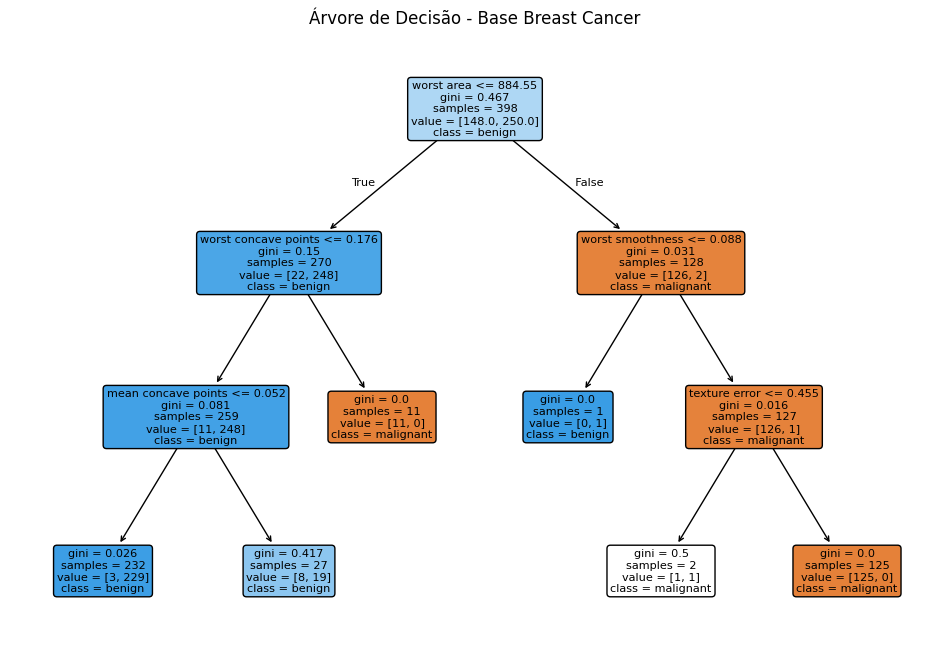

In [7]:
# Representação Gráfica da Árvore
gerar_grafico_da_arvore_de_decisao(clf, feature_names, target_names, 'Breast Cancer')

In [8]:
(y_pred_gnb, acuracia_gaussian, precisao_gaussian, revocacao_gaussian,
f1_gaussian) = executar_naive_bayes(X_train, y_train, X_test, y_test)


In [9]:
# Exibição dos resultados das métricas avaliadas usando Naive Bayes com Breast Cancer
exibir_resultado(
    acuracia_gaussian, precisao_gaussian,
    revocacao_gaussian, f1_gaussian,
    "NAIVE BAYES"
)


MÉTRICAS DE AVALIAÇÃO - NAIVE BAYES
Acurácia:  0.9532
Precisão:  0.9604
Revocação: 0.9406
F1-Score:  0.9490




In [10]:
# Exibição do relatório de classificação do Naive Bayes com Breast Cancer
exibir_relatorio_de_classificacao(y_test, y_pred_gnb, breast_cancer)


==================== RELATÓRIO DE CLASSIFICAÇÃO ====================
              precision    recall  f1-score   support

   malignant       0.98      0.89      0.93        64
      benign       0.94      0.99      0.96       107

    accuracy                           0.95       171
   macro avg       0.96      0.94      0.95       171
weighted avg       0.95      0.95      0.95       171



In [11]:
#Estabelecendo as variáveis que serão usadas no loop do KNN

valores_k = [1, 3, 5, 7, 9, 11]
resultados_acuracia = []
melhor_k = 1
melhor_f1 = 0

In [12]:
for k in valores_k:
    # Treinando e avalianndo o modelo de acordo com o K atual
    acuracia_knn, precisao_knn, revocacao_knn, f1_knn = treinar_k(
        k, resultados_acuracia, X_train, y_train, X_test, y_test
    )

    # Exibindo o resultado do K atual
    exibir_resultado(
        acuracia_knn, precisao_knn, revocacao_knn, f1_knn,
        f"KNN (K = {k})"
    )

    # Atualizando qual é o melhor modelo baseado no F1-Score
    melhor_f1, melhor_k = atualizar_melhor_desempenho_k(f1_knn, k, melhor_f1, melhor_k)

exibir_melhor_resultado_do_knn(melhor_k, melhor_f1)

MÉTRICAS DE AVALIAÇÃO - KNN (K = 1)
Acurácia:  0.8947
Precisão:  0.8876
Revocação: 0.8876
F1-Score:  0.8876


MÉTRICAS DE AVALIAÇÃO - KNN (K = 3)
Acurácia:  0.9006
Precisão:  0.8972
Revocação: 0.8892
F1-Score:  0.8928


MÉTRICAS DE AVALIAÇÃO - KNN (K = 5)
Acurácia:  0.9006
Precisão:  0.8972
Revocação: 0.8892
F1-Score:  0.8928


MÉTRICAS DE AVALIAÇÃO - KNN (K = 7)
Acurácia:  0.9006
Precisão:  0.8972
Revocação: 0.8892
F1-Score:  0.8928


MÉTRICAS DE AVALIAÇÃO - KNN (K = 9)
Acurácia:  0.9006
Precisão:  0.8972
Revocação: 0.8892
F1-Score:  0.8928


MÉTRICAS DE AVALIAÇÃO - KNN (K = 11)
Acurácia:  0.9006
Precisão:  0.8972
Revocação: 0.8892
F1-Score:  0.8928


CONCLUSÃO: O melhor desempenho foi com K = 3 (F1-Score: 0.8928)


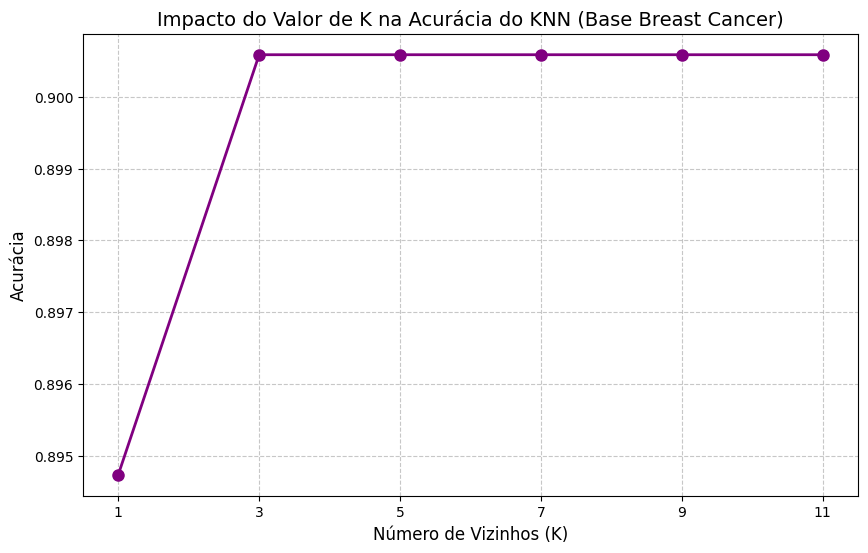

In [13]:
# Representação gráfica dos valores de K usados no KNN
exibir_grafico_comparativo(valores_k, resultados_acuracia, "Breast Cancer")
